In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [112]:
# Supaya tampilan grafik lebih rapi
plt.style.use('default')

# Load data 
df = pd.read_csv("PBPD 2025 MAGANG.csv")

# Lihat 5 data pertama
df.head()

,TGLMOHON,IDPEL,NAMA,ALAMAT,TARIF_LAMA,DAYA_LAMA,TARIF,DAYA,JENIS_TRANSAKSI
0,2/24/2025,511020884429,WYMAN PRAYUGO,JL JL. PLOSO TIMUR VA NO.7B - PLOSO TIMUR V ...,NaN,NaN,R1MT,900,PASANG BARU
1,2/12/2025,511020883960,IKA YUNITA SARI DR,"JL MOJOKLANGGRU KIDUL 1A NO 2F KALIJUDAN, M...",NaN,NaN,R1MT,900,PASANG BARU
2,3/17/2025,511020342707,NOR LATIFAH,GG KAPASARI PEDKH 8 NO. 11 RT.00 RW.00 00 ...,R1,900.0,R1T,900,PERUBAHAN DAYA
3,2/12/2025,511020883937,IKA YUNITA SARI DR,"JL MOJOKLANGGRU KIDUL 1A NO 2F KALIJUDAN, M...",NaN,NaN,R1MT,900,PASANG BARU
4,3/12/2025,511020886544,IDA AYU NUH KARTINI-3,JL SUTOREJO TENGAH No.36 RT.0 RW.0 MULYOREJODU...,NaN,NaN,R1T,1300,PASANG BARU


DATA CLEANING

In [113]:
# cek data
df.info()

# ubah format tanggal 
df['TGLMOHON'] = pd.to_datetime(df['TGLMOHON'])

# tambah kolom tahun dan bulan 
df['tahun'] = df['TGLMOHON'].dt.year
df['bulan'] = df['TGLMOHON'].dt.month
df['nama_bulan'] = df['TGLMOHON'].dt.strftime('%B')

# kolom selisi daya 
df['DAYA_LAMA'] = df['DAYA_LAMA'].fillna(0)
df['selisih_daya'] = df['DAYA'] - df['DAYA_LAMA']

# RAPI NAMA KOLOM
df.columns = df.columns.str.strip()   # hapus spasi tersembunyi
df.columns = df.columns.str.lower()   # ubah jadi huruf kecil

print(df.columns)

# rename nama kolom
df = df.rename(columns={
    'tglmohon': 'tanggal_permohonan',
    'idpel': 'id_pelanggan',
    'nama': 'nama_pelanggan',
    'alamat': 'alamat_pelanggan',
    'tarif': 'tarif_baru',
    'daya': 'daya_baru'
})

df.columns

# UBAH FORMAT TANGGAL
df['tanggal_permohonan'] = pd.to_datetime(df['tanggal_permohonan'], errors='coerce')

df.info()

# KOLOM NUMERIK BERSIH
df['daya_lama'] = pd.to_numeric(df['daya_lama'], errors='coerce')
df['daya_baru'] = pd.to_numeric(df['daya_baru'], errors='coerce')

# KOLOM SELISIS DAYA 
df['daya_lama'] = df['daya_lama'].fillna(0)

df['selisih_daya'] = df['daya_baru'] - df['daya_lama']

# KOLOM TAHUN & BULAN 
df['tahun'] = df['tanggal_permohonan'].dt.year
df['bulan'] = df['tanggal_permohonan'].dt.month
df['nama_bulan'] = df['tanggal_permohonan'].dt.strftime('%B')

# MISSING VALUE CEK 
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6905 entries, 0 to 6904
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TGLMOHON         6905 non-null   object 
 1   IDPEL            6905 non-null   int64  
 2   NAMA             6905 non-null   object 
 3   ALAMAT           6905 non-null   object 
 4   TARIF_LAMA       3274 non-null   object 
 5   DAYA_LAMA        3274 non-null   float64
 6   TARIF            6905 non-null   object 
 7   DAYA             6905 non-null   int64  
 8   JENIS_TRANSAKSI  6905 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 485.6+ KB
Index(['tglmohon', 'idpel', 'nama', 'alamat', 'tarif_lama', 'daya_lama',
       'tarif', 'daya', 'jenis_transaksi', 'tahun', 'bulan', 'nama_bulan',
       'selisih_daya'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6905 entries, 0 to 6904
Data columns (total 13 columns):
 #   Column            

tanggal_permohonan       0
id_pelanggan             0
nama_pelanggan           0
alamat_pelanggan         0
tarif_lama            3631
daya_lama                0
tarif_baru               0
daya_baru                0
jenis_transaksi          0
tahun                    0
bulan                    0
nama_bulan               0
selisih_daya             0
dtype: int64

ANALISIS TEMPORAL

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\2889536302.py:5: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



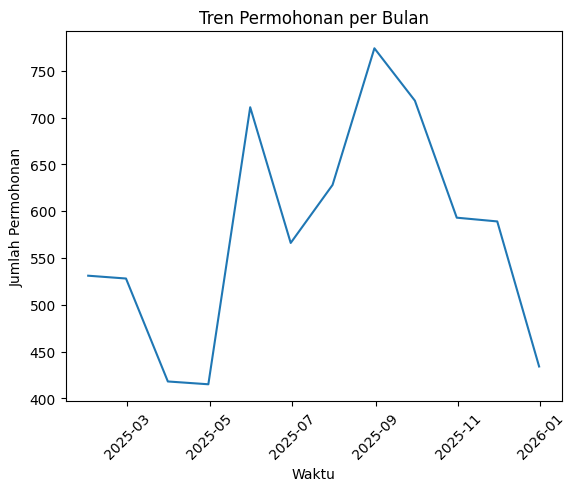

In [114]:
# jumlah permohonan per bulan 
# Agregasi jumlah permohonan per bulan
permohonan_bulanan = (
    df
    .groupby(pd.Grouper(key='tanggal_permohonan', freq='M'))
    .size()
    .reset_index(name='jumlah_permohonan')
)

plt.figure()
plt.plot(permohonan_bulanan['tanggal_permohonan'],
         permohonan_bulanan['jumlah_permohonan'])

plt.title("Tren Permohonan per Bulan")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)
plt.show()

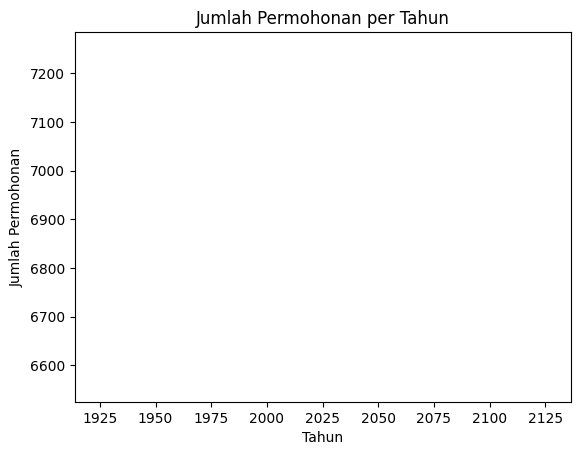

In [115]:
# jumlah permohonan per tahub
permohonan_tahunan = df.groupby('tahun').size().reset_index(name='jumlah')

plt.figure()
plt.plot(permohonan_tahunan['tahun'],
         permohonan_tahunan['jumlah'])

plt.title("Jumlah Permohonan per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Permohonan")
plt.show()

In [116]:
# bulan dengan permohonan tertinggi
top_bulan = (
    df.groupby('nama_bulan')
      .size()
      .sort_values(ascending=False)
)

print(top_bulan)


nama_bulan
August       774
September    718
May          711
July         628
October      593
November     589
June         566
January      531
February     528
December     434
March        418
April        415
dtype: int64


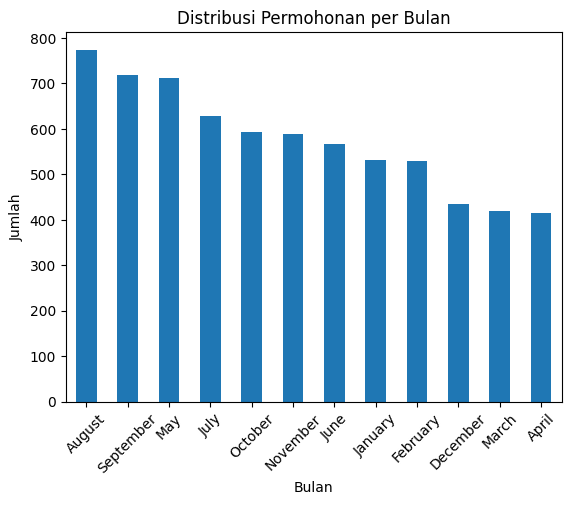

In [117]:
plt.figure()
top_bulan.plot(kind='bar')
plt.title("Distribusi Permohonan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

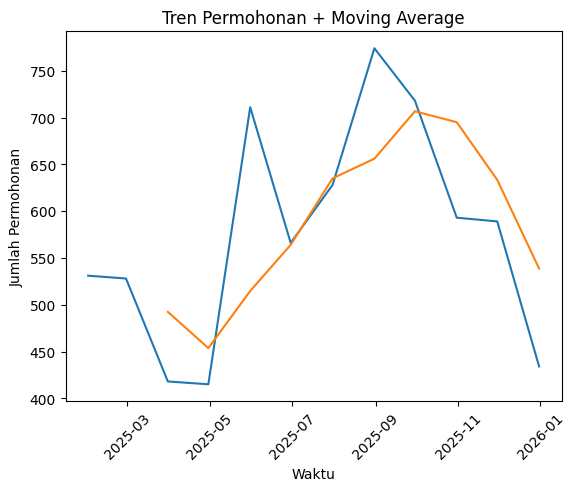

In [118]:
# Moving Average
permohonan_bulanan['moving_avg'] = (
    permohonan_bulanan['jumlah_permohonan']
    .rolling(window=3)
    .mean()
)

plt.figure()
plt.plot(permohonan_bulanan['tanggal_permohonan'],
         permohonan_bulanan['jumlah_permohonan'])

plt.plot(permohonan_bulanan['tanggal_permohonan'],
         permohonan_bulanan['moving_avg'])

plt.title("Tren Permohonan + Moving Average")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)
plt.show()

ANALISIS JENIS TRANSAKSI

In [119]:
# jumlah dan presentase 

import pandas as pd
import matplotlib.pyplot as plt

# Hitung jumlah per jenis transaksi
transaksi_counts = df['jenis_transaksi'].value_counts().reset_index()
transaksi_counts.columns = ['jenis_transaksi', 'jumlah']

# Hitung persentase
transaksi_counts['persentase (%)'] = (
    transaksi_counts['jumlah'] / transaksi_counts['jumlah'].sum() * 100
)

print(transaksi_counts)

  jenis_transaksi  jumlah  persentase (%)
0     PASANG BARU    3631       52.585083
1  PERUBAHAN DAYA    3274       47.414917


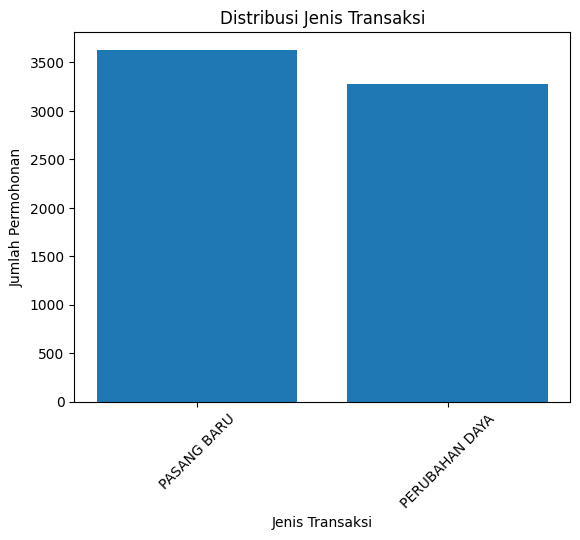

In [120]:
plt.figure()
plt.bar(transaksi_counts['jenis_transaksi'],
        transaksi_counts['jumlah'])

plt.title("Distribusi Jenis Transaksi")
plt.xlabel("Jenis Transaksi")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)
plt.show()

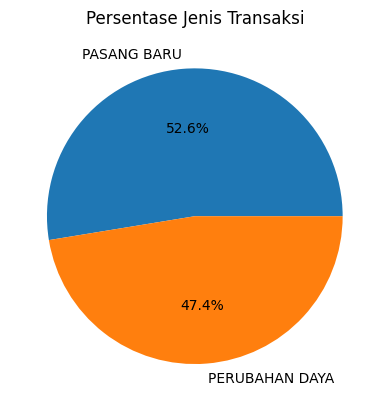

In [121]:
plt.figure()
plt.pie(transaksi_counts['jumlah'],
        labels=transaksi_counts['jenis_transaksi'],
        autopct='%1.1f%%')

plt.title("Persentase Jenis Transaksi")
plt.show()

ANALIS TREN TRANSAKSI

In [122]:
transaksi_tahunan = (
    df.groupby(['tahun', 'jenis_transaksi'])
      .size()
      .unstack()
      .fillna(0)
)

print(transaksi_tahunan)


jenis_transaksi  PASANG BARU  PERUBAHAN DAYA
tahun                                       
2025                    3631            3274


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\2993822804.py:11: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



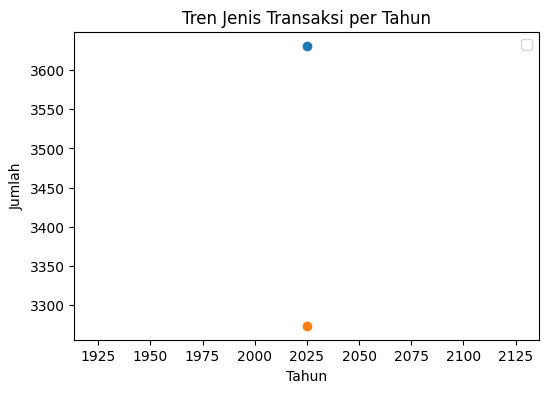

In [123]:
plt.figure(figsize=(6,4))

for kolom in transaksi_tahunan.columns:
    plt.plot(transaksi_tahunan.index,
             transaksi_tahunan[kolom],
             marker='o')

plt.title("Tren Jenis Transaksi per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah")
plt.legend()
plt.show()

<Figure size 600x400 with 0 Axes>

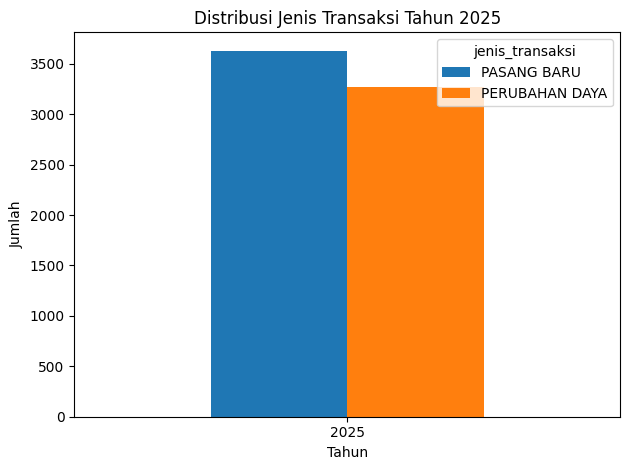

In [124]:
plt.figure(figsize=(6,4))

transaksi_tahunan.plot(kind='bar')

plt.title("Distribusi Jenis Transaksi Tahun 2025")
plt.xlabel("Tahun")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PER BULAN 

    bulan  jumlah_permohonan
0       1                531
1       2                528
2       3                418
3       4                415
4       5                711
5       6                566
6       7                628
7       8                774
8       9                718
9      10                593
10     11                589
11     12                434


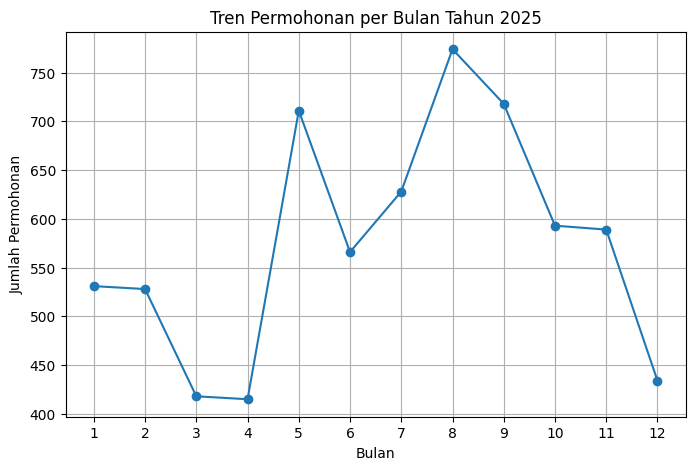

In [125]:
# jumlah permohonan per bulan 

import matplotlib.pyplot as plt

# Agregasi jumlah permohonan per bulan
permohonan_bulanan = (
    df.groupby('bulan')
      .size()
      .reset_index(name='jumlah_permohonan')
      .sort_values('bulan')
)

print(permohonan_bulanan)

# Plot
plt.figure(figsize=(8,5))
plt.plot(permohonan_bulanan['bulan'],
         permohonan_bulanan['jumlah_permohonan'],
         marker='o')

plt.title("Tren Permohonan per Bulan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Permohonan")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

jenis_transaksi  PASANG BARU  PERUBAHAN DAYA
bulan                                       
1                        222             309
2                        303             225
3                        212             206
4                        253             162
5                        381             330
6                        310             256
7                        383             245
8                        409             365
9                        317             401
10                       234             359
11                       345             244
12                       262             172


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\855497477.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



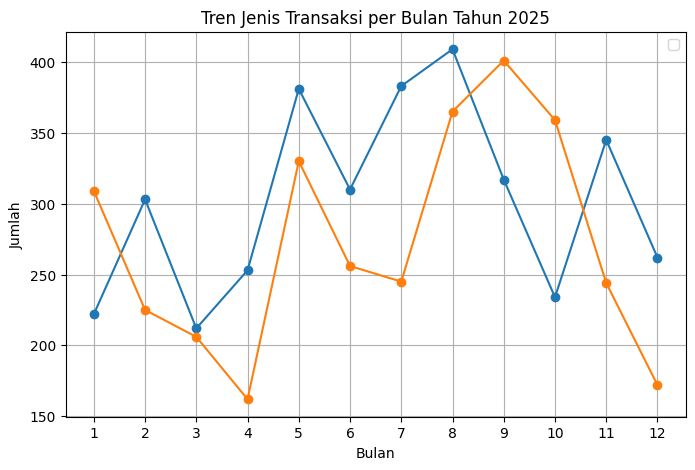

In [126]:
# Transaksi 

transaksi_bulanan = (
    df.groupby(['bulan', 'jenis_transaksi'])
      .size()
      .unstack()
      .fillna(0)
)

print(transaksi_bulanan)

plt.figure(figsize=(8,5))

for kolom in transaksi_bulanan.columns:
    plt.plot(transaksi_bulanan.index,
             transaksi_bulanan[kolom],
             marker='o')

plt.title("Tren Jenis Transaksi per Bulan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Jumlah")
plt.xticks(range(1,13))
plt.legend()
plt.grid(True)
plt.show()

In [127]:
# Permohonan tertinggi VS terendah 

bulan_tertinggi = permohonan_bulanan.loc[
    permohonan_bulanan['jumlah_permohonan'].idxmax()
]

bulan_terendah = permohonan_bulanan.loc[
    permohonan_bulanan['jumlah_permohonan'].idxmin()
]

print("Bulan Tertinggi:")
print(bulan_tertinggi)

print("\nBulan Terendah:")
print(bulan_terendah)

Bulan Tertinggi:
bulan                  8
jumlah_permohonan    774
Name: 7, dtype: int64

Bulan Terendah:
bulan                  4
jumlah_permohonan    415
Name: 3, dtype: int64


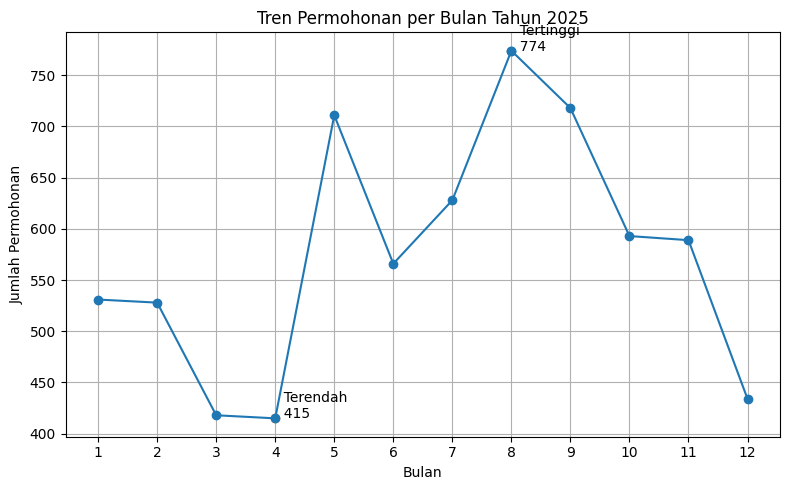

In [128]:
import matplotlib.pyplot as plt

# Agregasi jumlah permohonan per bulan
permohonan_bulanan = (
    df.groupby('bulan')
      .size()
      .reset_index(name='jumlah_permohonan')
      .sort_values('bulan')
)

# Cari bulan tertinggi & terendah
bulan_tertinggi = permohonan_bulanan.loc[
    permohonan_bulanan['jumlah_permohonan'].idxmax()
]

bulan_terendah = permohonan_bulanan.loc[
    permohonan_bulanan['jumlah_permohonan'].idxmin()
]

# Plot grafik
plt.figure(figsize=(8,5))
plt.plot(permohonan_bulanan['bulan'],
         permohonan_bulanan['jumlah_permohonan'],
         marker='o')

# Tandai bulan tertinggi
plt.scatter(bulan_tertinggi['bulan'],
            bulan_tertinggi['jumlah_permohonan'])

plt.text(bulan_tertinggi['bulan'],
         bulan_tertinggi['jumlah_permohonan'],
         f"  Tertinggi\n  {int(bulan_tertinggi['jumlah_permohonan'])}")

# Tandai bulan terendah
plt.scatter(bulan_terendah['bulan'],
            bulan_terendah['jumlah_permohonan'])

plt.text(bulan_terendah['bulan'],
         bulan_terendah['jumlah_permohonan'],
         f"  Terendah\n  {int(bulan_terendah['jumlah_permohonan'])}")

plt.title("Tren Permohonan per Bulan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Permohonan")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()

ANALISIS PERUBAHAN DAYA

In [129]:
# Statistik selisi perubahan daya 

# Statistik dasar
print("Statistik Selisih Daya:")
print(df['selisih_daya'].describe())

# Berapa yang menaikkan daya (>0)
menaikkan = (df['selisih_daya'] > 0).sum()
total = len(df)

print("\nJumlah pelanggan menaikkan daya:", menaikkan)
print("Persentase menaikkan daya:", round((menaikkan/total)*100,2), "%")

Statistik Selisih Daya:
count      6905.000000
mean       1676.698045
std        8667.391547
min      -97300.000000
25%         400.000000
50%         900.000000
75%        1300.000000
max      555000.000000
Name: selisih_daya, dtype: float64

Jumlah pelanggan menaikkan daya: 5700
Persentase menaikkan daya: 82.55 %


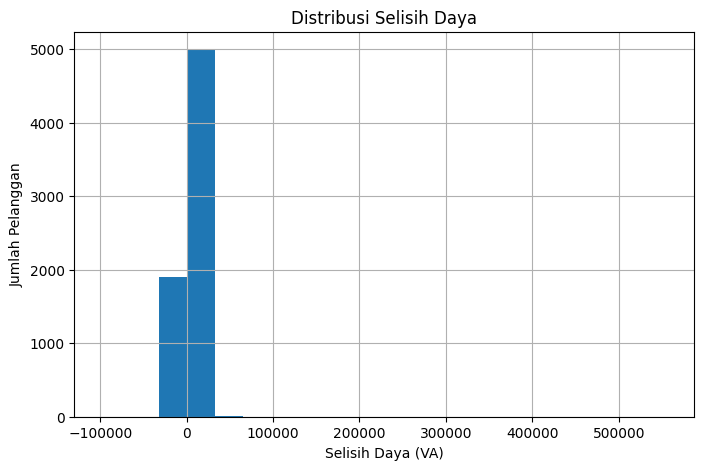

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['selisih_daya'], bins=20)

plt.title("Distribusi Selisih Daya")
plt.xlabel("Selisih Daya (VA)")
plt.ylabel("Jumlah Pelanggan")
plt.grid(True)
plt.show()

In [131]:
# rata-rata kenaikan daya 

rata_bulanan = (
    df.groupby('bulan')['selisih_daya']
      .mean()
      .reset_index()
      .sort_values('bulan')
)

print(rata_bulanan)

    bulan  selisih_daya
0       1   1230.037665
1       2   1339.204545
2       3   1315.430622
3       4   1497.108434
4       5   1369.690577
5       6   1670.583039
6       7   2375.955414
7       8   2460.400517
8       9   1293.523677
9      10   1827.487352
10     11   1669.100170
11     12   1693.087558


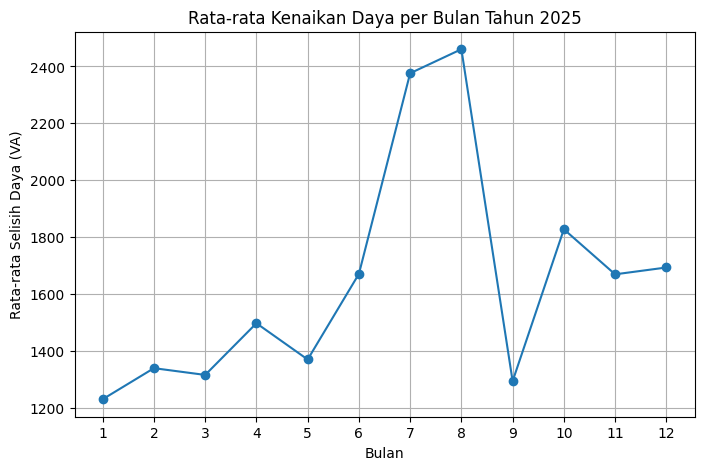

In [132]:
plt.figure(figsize=(8,5))
plt.plot(rata_bulanan['bulan'],
         rata_bulanan['selisih_daya'],
         marker='o')

plt.title("Rata-rata Kenaikan Daya per Bulan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Selisih Daya (VA)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

In [133]:
pip install ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [134]:
import nbformat
print(nbformat.__version__)

5.10.4


In [135]:
import sys
!{sys.executable} -m pip install nbformat ipython


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [136]:
heatmap_data = (
    df[df['bulan'].between(1,12)]
    .groupby(['bulan', 'jenis_transaksi'])
    .size()
    .unstack()
    .fillna(0)
)

In [137]:
print(sorted(df['bulan'].unique()))

[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [138]:
import pandas as pd
import plotly.express as px

# 🔥 Bersihkan data
df_clean = df[df['bulan'].between(1, 12)]

# 🔥 Mapping bulan
mapping_bulan = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
    7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'
}

df_clean['bulan_nama'] = df_clean['bulan'].map(mapping_bulan)

# 🔥 Grouping
heatmap_data = (
    df_clean
    .groupby(['bulan_nama', 'jenis_transaksi'])
    .size()
    .reset_index(name='jumlah')
)

# 🔥 Urutan bulan
urutan_bulan = list(mapping_bulan.values())
heatmap_data['bulan_nama'] = pd.Categorical(
    heatmap_data['bulan_nama'],
    categories=urutan_bulan,
    ordered=True
)

# 🔥 Heatmap TANPA angka di kotak
fig = px.density_heatmap(
    heatmap_data,
    x='jenis_transaksi',
    y='bulan_nama',
    z='jumlah',
    color_continuous_scale='RdYlGn_r'
    # ❌ tidak pakai text_auto
)

# 🔥 Hover custom (muncul saat diarahkan / klik)
fig.update_traces(
    hovertemplate=
    "<b>Bulan:</b> %{y}<br>" +
    "<b>Jenis:</b> %{x}<br>" +
    "<b>Jumlah:</b> %{z}<extra></extra>"
)

# 🔥 Layout compact
fig.update_layout(
    width=550,
    height=600,
    title={
        'text': "📊 Heatmap Permohonan Listrik",
        'x': 0.5
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=40, t=60, b=60)
)

fig.update_xaxes(tickangle=20)
fig.update_yaxes(showgrid=False)

fig.show()

In [142]:
# Growth Rate Bulanan
 
import pandas as pd
import matplotlib.pyplot as plt

# Total permohonan per bulan
permohonan_bulanan = (
    df.groupby('bulan')
      .size()
      .reset_index(name='jumlah')
      .sort_values('bulan')
)

print(permohonan_bulanan)

    bulan  jumlah
0       1     531
1       2     528
2       3     418
3       4     415
4       5     711
5       6     566
6       7     628
7       8     774
8       9     718
9      10     593
10     11     589
11     12     434


In [143]:

# Hitung growth rate
permohonan_bulanan['growth_%'] = (
    permohonan_bulanan['jumlah']
    .pct_change() * 100
)

print(permohonan_bulanan)

    bulan  jumlah   growth_%
0       1     531        NaN
1       2     528  -0.564972
2       3     418 -20.833333
3       4     415  -0.717703
4       5     711  71.325301
5       6     566 -20.393812
6       7     628  10.954064
7       8     774  23.248408
8       9     718  -7.235142
9      10     593 -17.409471
10     11     589  -0.674536
11     12     434 -26.315789


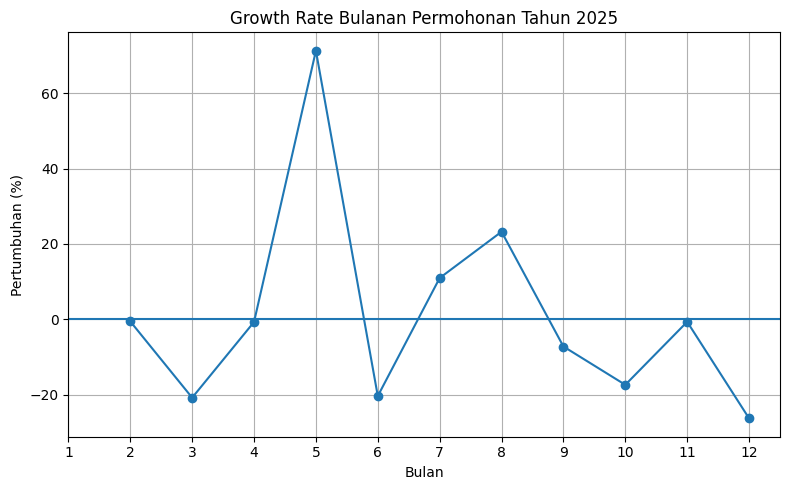

In [144]:
plt.figure(figsize=(8,5))

plt.plot(permohonan_bulanan['bulan'],
         permohonan_bulanan['growth_%'],
         marker='o')

plt.axhline(0)  # garis nol untuk pembanding

plt.title("Growth Rate Bulanan Permohonan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Pertumbuhan (%)")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()

In [145]:
# deteksi lonjakan dan penurunan 

bulan_tertinggi = permohonan_bulanan.loc[
    permohonan_bulanan['growth_%'].idxmax()
]

bulan_terendah = permohonan_bulanan.loc[
    permohonan_bulanan['growth_%'].idxmin()
]

print("Lonjakan Tertinggi:")
print(bulan_tertinggi)

print("\nPenurunan Terbesar:")
print(bulan_terendah)

Lonjakan Tertinggi:
bulan         5.000000
jumlah      711.000000
growth_%     71.325301
Name: 4, dtype: float64

Penurunan Terbesar:
bulan        12.000000
jumlah      434.000000
growth_%    -26.315789
Name: 11, dtype: float64


ANALISIS SPASIAL

In [146]:
# Ekstrak kecamatan dari alamat
df['kecamatan'] = (
    df['alamat_pelanggan']
    .str.split(',')
    .str[-3]      # ambil bagian sebelum kota
    .str.strip()
)

print(df[['alamat_pelanggan','kecamatan']].head())

                                    alamat_pelanggan   kecamatan
0  JL JL. PLOSO TIMUR VA NO.7B - PLOSO TIMUR V   ...  TAMBAKSARI
1  JL MOJOKLANGGRU KIDUL 1A NO 2F    KALIJUDAN, M...   MULYOREJO
2  GG KAPASARI PEDKH 8   NO. 11 RT.00 RW.00 00   ...   SIMOKERTO
3  JL MOJOKLANGGRU KIDUL 1A NO 2F    KALIJUDAN, M...   MULYOREJO
4  JL SUTOREJO TENGAH No.36 RT.0 RW.0 MULYOREJODU...   MULYOREJO


In [147]:
# Jumlah per mohonan per kecamatan 
permohonan_kecamatan = (
    df.groupby('kecamatan')
      .size()
      .reset_index(name='jumlah_permohonan')
      .sort_values('jumlah_permohonan', ascending=False)
)

print(permohonan_kecamatan)

    kecamatan  jumlah_permohonan
3   MULYOREJO               3401
5  TAMBAKSARI               3092
4   SIMOKERTO                245
1      GUBENG                165
0     GENTENG                  1
2    KENJERAN                  1


In [148]:
import folium

# Titik tengah Surabaya
peta = folium.Map(location=[-7.2575, 112.7521], zoom_start=12)

# Tambahkan marker untuk setiap kecamatan
for _, row in permohonan_kecamatan.iterrows():
    folium.Marker(
        location=[-7.25, 112.75],  # sementara titik pusat (nanti kita bisa buat lebih akurat)
        popup=f"{row['kecamatan']} : {row['jumlah_permohonan']}",
    ).add_to(peta)

peta
peta.save("peta_permohonan.html")

In [149]:
df['kecamatan'] = (
    df['kecamatan']
    .str.upper()
    .str.strip()
)

permohonan_kecamatan = (
    df.groupby('kecamatan')
      .size()
      .reset_index(name='jumlah')
)

print(permohonan_kecamatan.head())

   kecamatan  jumlah
0    GENTENG       1
1     GUBENG     165
2   KENJERAN       1
3  MULYOREJO    3401
4  SIMOKERTO     245


In [150]:
kecamatan_fokus = [
    "GENTENG",
    "GUBENG",
    "KENJERAN",
    "MULYOREJO",
    "SIMOKERTO",
    "TAMBAKSARI"
]

df['kecamatan'] = df['kecamatan'].str.upper().str.strip()
df_fokus = df[df['kecamatan'].isin(kecamatan_fokus)]

print(df_fokus['kecamatan'].value_counts())

kecamatan
MULYOREJO     3401
TAMBAKSARI    3092
SIMOKERTO      245
GUBENG         165
GENTENG          1
KENJERAN         1
Name: count, dtype: int64


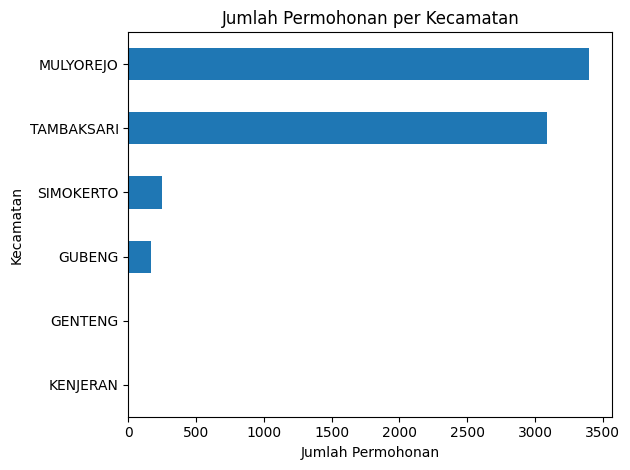

In [151]:
import matplotlib.pyplot as plt

jumlah_kecamatan = df_fokus['kecamatan'].value_counts().sort_values()

plt.figure()
jumlah_kecamatan.plot(kind='barh')
plt.title("Jumlah Permohonan per Kecamatan")
plt.xlabel("Jumlah Permohonan")
plt.ylabel("Kecamatan")
plt.tight_layout()
plt.show()

In [152]:
import folium

# Koordinat centroid perkiraan
koordinat = {
    "GENTENG": [-7.265, 112.747],
    "GUBENG": [-7.276, 112.758],
    "KENJERAN": [-7.235, 112.800],
    "MULYOREJO": [-7.275, 112.785],
    "SIMOKERTO": [-7.245, 112.750],
    "TAMBAKSARI": [-7.255, 112.760],
}

jumlah = df_fokus['kecamatan'].value_counts().reset_index()
jumlah.columns = ['kecamatan','total']

peta = folium.Map(location=[-7.26, 112.77], zoom_start=12)

for _, row in jumlah.iterrows():
    kec = row['kecamatan']
    total = row['total']
    
    if kec in koordinat:
        folium.CircleMarker(
            location=koordinat[kec],
            radius=total/200,
            popup=f"{kec}: {total} permohonan",
            fill=True
        ).add_to(peta)

peta.save("peta_6_kecamatan.html")
peta

PERMOHONAN PASANG BARU VS TAMBAH DAYA 

In [153]:
df_fokus['jenis_transaksi'] = df_fokus['jenis_transaksi'].str.upper().str.strip()

df_fokus['jenis_transaksi'].value_counts()

jenis_transaksi
PASANG BARU       3631
PERUBAHAN DAYA    3274
Name: count, dtype: int64

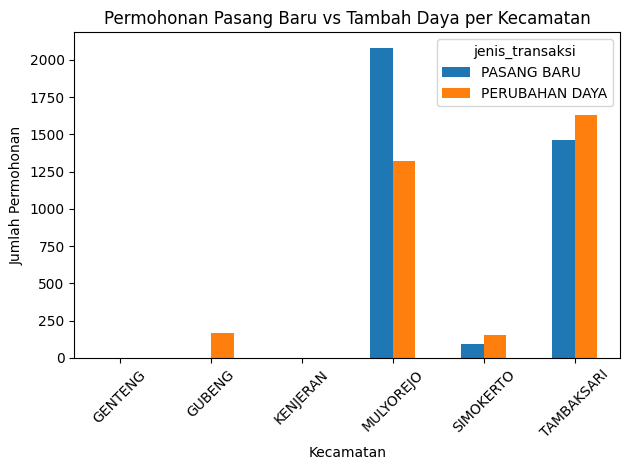

In [154]:
import matplotlib.pyplot as plt

pivot_layanan = pd.crosstab(
    df_fokus['kecamatan'],
    df_fokus['jenis_transaksi']
)

pivot_layanan.plot(kind='bar')
plt.title("Permohonan Pasang Baru vs Tambah Daya per Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

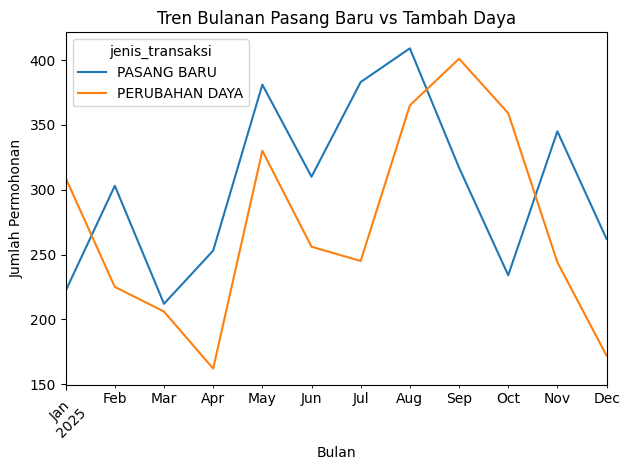

In [155]:
# temporal per bulan 

df_fokus['tanggal_permohonan'] = pd.to_datetime(df_fokus['tanggal_permohonan'])
df_fokus['bulan'] = df_fokus['tanggal_permohonan'].dt.to_period('M')

tren = (
    df_fokus.groupby(['bulan','jenis_transaksi'])
    .size()
    .unstack()
)

tren.plot()
plt.title("Tren Bulanan Pasang Baru vs Tambah Daya")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [156]:
import folium
import pandas as pd

# Bersihkan format
df_fokus['jenis_transaksi'] = df_fokus['jenis_transaksi'].str.upper().str.strip()

# Pivot jumlah
pivot = pd.crosstab(
    df_fokus['kecamatan'],
    df_fokus['jenis_transaksi']
).reset_index()

# Pastikan kolom ada
if 'PASANG BARU' not in pivot.columns:
    pivot['PASANG BARU'] = 0
if 'TAMBAH DAYA' not in pivot.columns:
    pivot['TAMBAH DAYA'] = 0

pivot['TOTAL'] = pivot['PASANG BARU'] + pivot['TAMBAH DAYA']

# Hitung persentase
pivot['% PASANG BARU'] = (pivot['PASANG BARU'] / pivot['TOTAL'] * 100).round(1)
pivot['% TAMBAH DAYA'] = (pivot['TAMBAH DAYA'] / pivot['TOTAL'] * 100).round(1)

# Koordinat centroid
koordinat = {
    "GENTENG": [-7.265, 112.747],
    "GUBENG": [-7.276, 112.758],
    "KENJERAN": [-7.235, 112.800],
    "MULYOREJO": [-7.275, 112.785],
    "SIMOKERTO": [-7.245, 112.750],
    "TAMBAKSARI": [-7.255, 112.760],
}

peta = folium.Map(location=[-7.26, 112.77], zoom_start=12)

for _, row in pivot.iterrows():
    kec = row['kecamatan']
    
    if kec in koordinat:
        
        # Tentukan dominasi
        if row['PASANG BARU'] > row['TAMBAH DAYA']:
            warna = "blue"
            dominasi = "Pasang Baru"
        elif row['TAMBAH DAYA'] > row['PASANG BARU']:
            warna = "red"
            dominasi = "Tambah Daya"
        else:
            warna = "gray"
            dominasi = "Seimbang"
        
        folium.CircleMarker(
            location=koordinat[kec],
            radius=row['TOTAL']/200,
            color=warna,
            fill=True,
            fill_color=warna,
            fill_opacity=0.6,
            popup=f"""
            <b>{kec}</b><br><br>
            Pasang Baru: {row['PASANG BARU']} ({row['% PASANG BARU']}%)<br>
            Tambah Daya: {row['TAMBAH DAYA']} ({row['% TAMBAH DAYA']}%)<br><br>
            <b>Dominasi: {dominasi}</b><br>
            Total: {row['TOTAL']}
            """
        ).add_to(peta)

peta.save("peta_penyebaran vs tambah daya.html")
peta

In [157]:
# tabel rangking kecamatan 

# Pivot jumlah layanan
pivot = pd.crosstab(
    df_fokus['kecamatan'],
    df_fokus['jenis_transaksi']
).reset_index()

# Pastikan kolom ada
if 'PASANG BARU' not in pivot.columns:
    pivot['PASANG BARU'] = 0
if 'TAMBAH DAYA' not in pivot.columns:
    pivot['TAMBAH DAYA'] = 0

# Hitung total
pivot['TOTAL'] = pivot['PASANG BARU'] + pivot['TAMBAH DAYA']

# Ranking
pivot['RANK_TOTAL'] = pivot['TOTAL'].rank(ascending=False).astype(int)
pivot['RANK_PASANG_BARU'] = pivot['PASANG BARU'].rank(ascending=False).astype(int)
pivot['RANK_TAMBAH_DAYA'] = pivot['TAMBAH DAYA'].rank(ascending=False).astype(int)

# Urutkan berdasarkan total
ranking = pivot.sort_values('RANK_TOTAL')

ranking

jenis_transaksi,kecamatan,PASANG BARU,PERUBAHAN DAYA,TAMBAH DAYA,TOTAL,RANK_TOTAL,RANK_PASANG_BARU,RANK_TAMBAH_DAYA
3,MULYOREJO,2081,1320,0,2081,1,1,3
5,TAMBAKSARI,1460,1632,0,1460,2,2,3
4,SIMOKERTO,90,155,0,90,3,3,3
0,GENTENG,0,1,0,0,5,5,3
2,KENJERAN,0,1,0,0,5,5,3
1,GUBENG,0,165,0,0,5,5,3


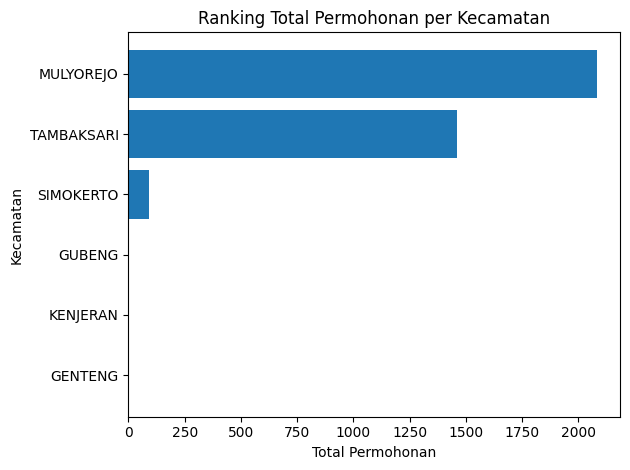

In [158]:
import matplotlib.pyplot as plt

ranking_sorted = ranking.sort_values('TOTAL')

plt.figure()
plt.barh(ranking_sorted['kecamatan'], ranking_sorted['TOTAL'])
plt.title("Ranking Total Permohonan per Kecamatan")
plt.xlabel("Total Permohonan")
plt.ylabel("Kecamatan")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

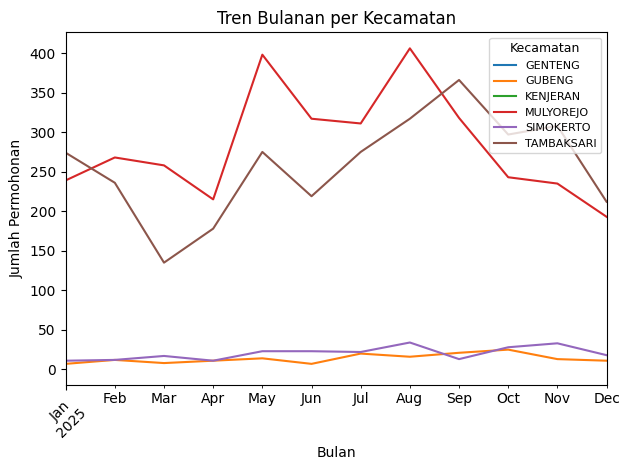

In [159]:
import matplotlib.pyplot as plt

tren_kecamatan = (
    df_fokus.groupby(['bulan','kecamatan'])
    .size()
    .unstack()
)

plt.figure()
tren_kecamatan.plot()

plt.title("Tren Bulanan per Kecamatan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Permohonan")
plt.xticks(rotation=45)

# Atur legend
plt.legend(
    title="Kecamatan",
    loc="upper right",      # kanan atas
    fontsize=8,             # ukuran kecil
    title_fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

Growth kecamatan 

<Figure size 640x480 with 0 Axes>

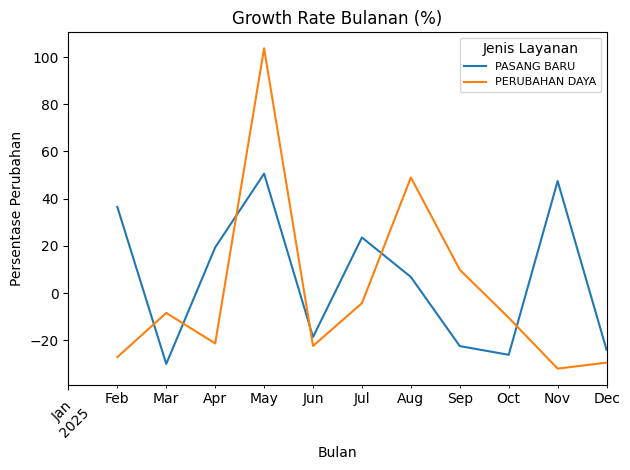

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan kolom tanggal sudah datetime
df_fokus['tanggal_permohonan'] = pd.to_datetime(df_fokus['tanggal_permohonan'])
df_fokus['bulan'] = df_fokus['tanggal_permohonan'].dt.to_period('M')

# Agregasi bulanan per layanan
tren_bulanan = (
    df_fokus.groupby(['bulan','jenis_transaksi'])
    .size()
    .unstack()
)

# Hitung growth rate (%)
growth_bulanan = tren_bulanan.pct_change() * 100

# Plot growth rate
plt.figure()
growth_bulanan.plot()
plt.title("Growth Rate Bulanan (%)")
plt.xlabel("Bulan")
plt.ylabel("Persentase Perubahan")
plt.xticks(rotation=45)

plt.legend(
    title="Jenis Layanan",
    loc="upper right",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [161]:
# kecamatan dengan pertumbuhan tercepat 

# Total bulanan per kecamatan
tren_kecamatan = (
    df_fokus.groupby(['bulan','kecamatan'])
    .size()
    .unstack()
)

# Hitung growth rate per kecamatan
growth_kecamatan = tren_kecamatan.pct_change() * 100

# Hitung rata-rata growth tiap kecamatan
rata_growth = growth_kecamatan.mean().sort_values(ascending=False)

rata_growth

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\2558744176.py:11: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



kecamatan
GUBENG        18.681387
SIMOKERTO     18.252228
TAMBAKSARI     1.754609
MULYOREJO      1.702725
GENTENG        0.000000
KENJERAN       0.000000
dtype: float64

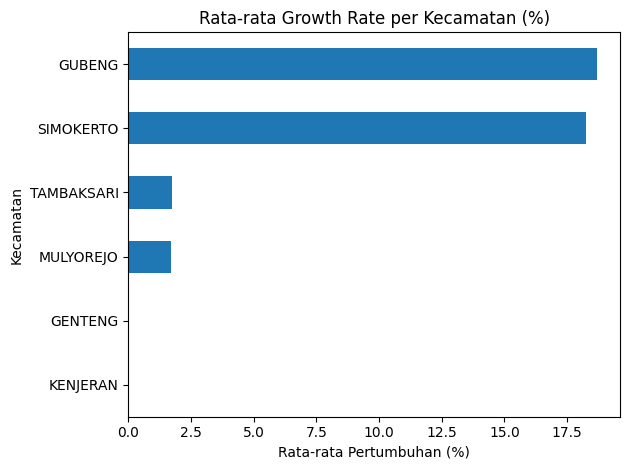

In [162]:
plt.figure()
rata_growth.sort_values().plot(kind='barh')
plt.title("Rata-rata Growth Rate per Kecamatan (%)")
plt.xlabel("Rata-rata Pertumbuhan (%)")
plt.ylabel("Kecamatan")
plt.tight_layout()
plt.show()

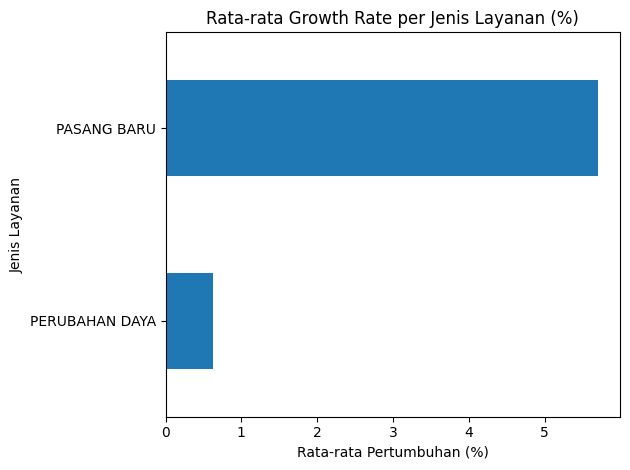

In [163]:
# perbandingan pemasangan VS tambah daya 

# Rata-rata growth tiap layanan
rata_growth_layanan = growth_bulanan.mean().sort_values(ascending=False)

rata_growth_layanan

plt.figure()
rata_growth_layanan.sort_values().plot(kind='barh')
plt.title("Rata-rata Growth Rate per Jenis Layanan (%)")
plt.xlabel("Rata-rata Pertumbuhan (%)")
plt.ylabel("Jenis Layanan")
plt.tight_layout()
plt.show()

KLASIFIKASI BEDASARKAN WILAYA

In [164]:
import pandas as pd
import matplotlib.pyplot as plt


# Q1 → Low
# Q2–Q3 → Medium
# Q4 → High

# Hitung total permohonan per kecamatan
total_kecamatan = (
    df_fokus.groupby('kecamatan')
    .size()
    .reset_index(name='TOTAL')
)

# Hitung kuartil
Q1 = total_kecamatan['TOTAL'].quantile(0.25)
Q3 = total_kecamatan['TOTAL'].quantile(0.75)

# Fungsi klasifikasi
def klasifikasi(total):
    if total <= Q1:
        return "Low Demand"
    elif total >= Q3:
        return "High Demand"
    else:
        return "Medium Demand"

total_kecamatan['Kategori'] = total_kecamatan['TOTAL'].apply(klasifikasi)

# Urutkan dari tertinggi
total_kecamatan = total_kecamatan.sort_values('TOTAL', ascending=False)

total_kecamatan

,kecamatan,TOTAL,Kategori
3,MULYOREJO,3401,High Demand
5,TAMBAKSARI,3092,High Demand
4,SIMOKERTO,245,Medium Demand
1,GUBENG,165,Medium Demand
0,GENTENG,1,Low Demand
2,KENJERAN,1,Low Demand


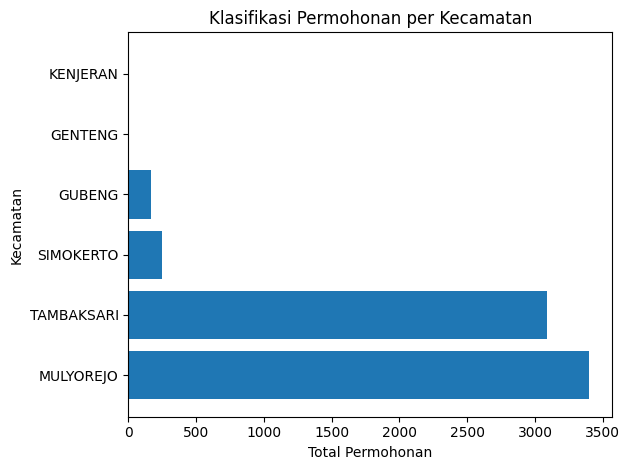

In [165]:
plt.figure()
plt.barh(total_kecamatan['kecamatan'], total_kecamatan['TOTAL'])
plt.title("Klasifikasi Permohonan per Kecamatan")
plt.xlabel("Total Permohonan")
plt.ylabel("Kecamatan")
plt.tight_layout()
plt.show()

In [166]:
# peta FIKS 

import pandas as pd
import folium

# Bersihkan format layanan
df_fokus['jenis_transaksi'] = df_fokus['jenis_transaksi'].str.upper().str.strip()

# Pivot jumlah layanan per kecamatan
pivot = pd.crosstab(
    df_fokus['kecamatan'],
    df_fokus['jenis_transaksi']
).reset_index()

# Pastikan kolom ada
if 'PASANG BARU' not in pivot.columns:
    pivot['PASANG BARU'] = 0
if 'TAMBAH DAYA' not in pivot.columns:
    pivot['TAMBAH DAYA'] = 0

pivot['TOTAL'] = pivot['PASANG BARU'] + pivot['TAMBAH DAYA']

# Hitung kuartil
Q1 = pivot['TOTAL'].quantile(0.25)
Q3 = pivot['TOTAL'].quantile(0.75)

def klasifikasi(total):
    if total <= Q1:
        return "Low Demand"
    elif total >= Q3:
        return "High Demand"
    else:
        return "Medium Demand"

pivot['Kategori'] = pivot['TOTAL'].apply(klasifikasi)

In [ ]:
koordinat = {
    "GENTENG": [-7.265, 112.747],
    "GUBENG": [-7.276, 112.758],
    "KENJERAN": [-7.235, 112.800],
    "MULYOREJO": [-7.275, 112.785],
    "SIMOKERTO": [-7.245, 112.750],
    "TAMBAKSARI": [-7.255, 112.760],
}

In [167]:
# Buat peta dasar
peta = folium.Map(location=[-7.26, 112.77], zoom_start=12)

for _, row in pivot.iterrows():
    kec = row['kecamatan']
    
    if kec in koordinat:
        
        # Tentukan warna
        if row['Kategori'] == "High Demand":
            warna = "red"
        elif row['Kategori'] == "Medium Demand":
            warna = "orange"
        else:
            warna = "green"
        
        folium.CircleMarker(
            location=koordinat[kec],
            radius=row['TOTAL']/200,
            color=warna,
            fill=True,
            fill_color=warna,
            fill_opacity=0.7,
            popup=f"""
            <b>{kec}</b><br><br>
            Pasang Baru: {row['PASANG BARU']}<br>
            Tambah Daya: {row['TAMBAH DAYA']}<br>
            Total: {row['TOTAL']}<br><br>
            <b>Kategori: {row['Kategori']}</b>
            """
        ).add_to(peta)

legend_html = """
<div style="
position: fixed; 
top: 20px; right: 20px; width: 150px; 
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:12px;
padding: 10px;
">
<b>Kategori Demand</b><br>
<i style="color:red;">●</i> High Demand<br>
<i style="color:orange;">●</i> Medium Demand<br>
<i style="color:green;">●</i> Low Demand
</div>
"""

peta.get_root().html.add_child(folium.Element(legend_html))

peta.save("peta_pln penyebaran vs tambah daya.html")
peta

INTEGRITAS SPASIAL + TEMPORAL 

In [168]:
# siapkan data bulanan 

import pandas as pd

# Pastikan format datetime
df_fokus['tanggal_permohonan'] = pd.to_datetime(df_fokus['tanggal_permohonan'])

# Buat kolom bulan
df_fokus['bulan'] = df_fokus['tanggal_permohonan'].dt.to_period('M')

In [169]:
# hitung total per kecamatan

# Hitung total layanan per kecamatan per bulan
spatio_temporal = df_fokus.groupby(['bulan', 'kecamatan']).size().reset_index(name='TOTAL')

spatio_temporal.head()

,bulan,kecamatan,TOTAL
0,2025-01,GUBENG,7
1,2025-01,MULYOREJO,239
2,2025-01,SIMOKERTO,11
3,2025-01,TAMBAKSARI,274
4,2025-02,GUBENG,12


In [170]:
# klasifikasi hight,medium,low per bulan 

def klasifikasi_bulanan(df):
    Q1 = df['TOTAL'].quantile(0.25)
    Q3 = df['TOTAL'].quantile(0.75)
    
    def kategori(x):
        if x <= Q1:
            return "Low"
        elif x >= Q3:
            return "High"
        else:
            return "Medium"
    
    df['Kategori'] = df['TOTAL'].apply(kategori)
    return df

spatio_temporal = spatio_temporal.groupby('bulan').apply(klasifikasi_bulanan)
spatio_temporal.reset_index(drop=True, inplace=True)

spatio_temporal.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\1649588806.py:18: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,bulan,kecamatan,TOTAL,Kategori
0,2025-01,GUBENG,7,Low
1,2025-01,MULYOREJO,239,Medium
2,2025-01,SIMOKERTO,11,Medium
3,2025-01,TAMBAKSARI,274,High
4,2025-02,GUBENG,12,Low


In [171]:
# perubhan kategori per kecamatan

pivot_kategori = spatio_temporal.pivot(
    index='kecamatan',
    columns='bulan',
    values='Kategori'
)

pivot_kategori

bulan,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
kecamatan,,,,,,,,,,,,
GENTENG,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GUBENG,Low,Low,Low,Low,Low,Low,Low,Low,Medium,Low,Low,Low
KENJERAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN
MULYOREJO,Medium,High,High,High,High,High,High,High,Medium,Medium,Medium,Medium
SIMOKERTO,Medium,Low,Medium,Low,Medium,Medium,Medium,Medium,Low,Medium,Medium,Medium
TAMBAKSARI,High,Medium,Medium,Medium,High,Medium,Medium,High,High,High,High,High


In [172]:
# Kecamatan Konsisten High Demand
konsisten_high = pivot_kategori[
    pivot_kategori.apply(lambda row: (row == "High").sum(), axis=1) >= len(pivot_kategori.columns)*0.6
]

konsisten_high

bulan,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
kecamatan,,,,,,,,,,,,


In [173]:
# kecamatan yang naik dari medium ke hight

transisi = []

for kec in pivot_kategori.index:
    kategori_list = pivot_kategori.loc[kec].values
    
    for i in range(len(kategori_list)-1):
        if kategori_list[i] == "Medium" and kategori_list[i+1] == "High":
            transisi.append(kec)

kecamatan_naik = list(set(transisi))

kecamatan_naik

['MULYOREJO', 'TAMBAKSARI']

In [175]:
import pandas as pd
import plotly.express as px

# Copy data
heatmap_data = pivot_kategori.copy()

# Mapping kategori
mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}
heatmap_data = heatmap_data.replace(mapping)

# Reset index
heatmap_data = heatmap_data.reset_index()

# Ubah ke long format
heatmap_long = heatmap_data.melt(
    id_vars=heatmap_data.columns[0],
    var_name='bulan',
    value_name='kategori'
)

heatmap_long.columns = ['kecamatan', 'bulan', 'kategori']

# 🔥 FIX ERROR: ubah Period → string
heatmap_long['bulan'] = heatmap_long['bulan'].astype(str)

# Plot
fig = px.density_heatmap(
    heatmap_long,
    x='bulan',
    y='kecamatan',
    z='kategori',
    color_continuous_scale='RdYlGn_r'
)

# Hover
fig.update_traces(
    hovertemplate=
    "<b>Kecamatan:</b> %{y}<br>" +
    "<b>Bulan:</b> %{x}<br>" +
    "<b>Kategori:</b> %{z}<extra></extra>"
)

# Layout
fig.update_layout(
    width=600,
    height=550,
    title={'text': "📊 Heatmap Kategori Demand", 'x': 0.5},
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=80, r=40, t=60, b=60)
)

fig.update_xaxes(tickangle=30)
fig.update_yaxes(showgrid=False)

fig.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23872\3640522822.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



SPATIAL CLUSTERING + HOSPOT ANLAYSIS

In [184]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [180]:
print(df.columns.tolist())

['tanggal_permohonan', 'id_pelanggan', 'nama_pelanggan', 'alamat_pelanggan', 'tarif_lama', 'daya_lama', 'tarif_baru', 'daya_baru', 'jenis_transaksi', 'tahun', 'bulan', 'nama_bulan', 'selisih_daya', 'kecamatan']


In [187]:
# =========================
# BUAT DATA AGREGASI
# =========================

# ekstrak kecamatan
df["kecamatan"] = (
    df["alamat_pelanggan"]
    .str.split(",")
    .str[-3]
    .str.upper()
    .str.strip()
)

# fokus wilayah
kecamatan_fokus = [
    "GENTENG",
    "GUBENG",
    "KENJERAN",
    "MULYOREJO",
    "SIMOKERTO",
    "TAMBAKSARI"
]

df_fokus = df[df["kecamatan"].isin(kecamatan_fokus)]

# hitung agregasi
agregasi = df_fokus.groupby("kecamatan").agg({
    "selisih_daya": "mean",
    "id_pelanggan": "count"
}).reset_index()

agregasi.columns = [
    "kecamatan",
    "rata_selisi_daya",
    "total_permohonan"
]

# hitung pasang baru
pb = (
    df_fokus[df_fokus["jenis_transaksi"] == "pasang baru"]
    .groupby("kecamatan")
    .size()
)

# hitung tambah daya
td = (
    df_fokus[df_fokus["jenis_transaksi"] == "perubahan daya"]
    .groupby("kecamatan")
    .size()
)

agregasi["pasang_baru"] = agregasi["kecamatan"].map(pb).fillna(0)
agregasi["tambah_daya"] = agregasi["kecamatan"].map(td).fillna(0)

print(agregasi)

    kecamatan  rata_selisi_daya  total_permohonan  pasang_baru  tambah_daya
0     GENTENG       3300.000000                 1          0.0          0.0
1      GUBENG       1247.272727               165          0.0          0.0
2    KENJERAN          0.000000                 1          0.0          0.0
3   MULYOREJO       2191.737724              3401          0.0          0.0
4   SIMOKERTO        946.122449               245          0.0          0.0
5  TAMBAKSARI       1191.009056              3092          0.0          0.0


In [188]:
# =========================
# SPATIAL CLUSTERING
# =========================

cluster_data = agregasi[[
    'total_permohonan',
    'pasang_baru',
    'tambah_daya',
    'rata_selisi_daya'
]]

print(cluster_data)

   total_permohonan  pasang_baru  tambah_daya  rata_selisi_daya
0                 1          0.0          0.0       3300.000000
1               165          0.0          0.0       1247.272727
2                 1          0.0          0.0          0.000000
3              3401          0.0          0.0       2191.737724
4               245          0.0          0.0        946.122449
5              3092          0.0          0.0       1191.009056


In [189]:
# standardisasi
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [190]:
# model kmeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# fitting
agregasi['CLUSTER'] = kmeans.fit_predict(scaled_data)

print(agregasi[['kecamatan','CLUSTER']])

    kecamatan  CLUSTER
0     GENTENG        2
1      GUBENG        0
2    KENJERAN        0
3   MULYOREJO        1
4   SIMOKERTO        0
5  TAMBAKSARI        1


In [191]:
# rata-rata total per cluster
cluster_rank = (
    agregasi.groupby('CLUSTER')['total_permohonan']
    .mean()
    .sort_values()
)

print(cluster_rank)

CLUSTER
2       1.0
0     137.0
1    3246.5
Name: total_permohonan, dtype: float64


In [193]:
mapping = {
    1: 'Low Demand',
    0: 'Medium Demand',
    2: 'High Demand'
}

agregasi['KATEGORI_CLUSTER'] = agregasi['CLUSTER'].map(mapping)

print(agregasi[
    ['kecamatan','KATEGORI_CLUSTER']
])

    kecamatan KATEGORI_CLUSTER
0     GENTENG      High Demand
1      GUBENG    Medium Demand
2    KENJERAN    Medium Demand
3   MULYOREJO       Low Demand
4   SIMOKERTO    Medium Demand
5  TAMBAKSARI       Low Demand


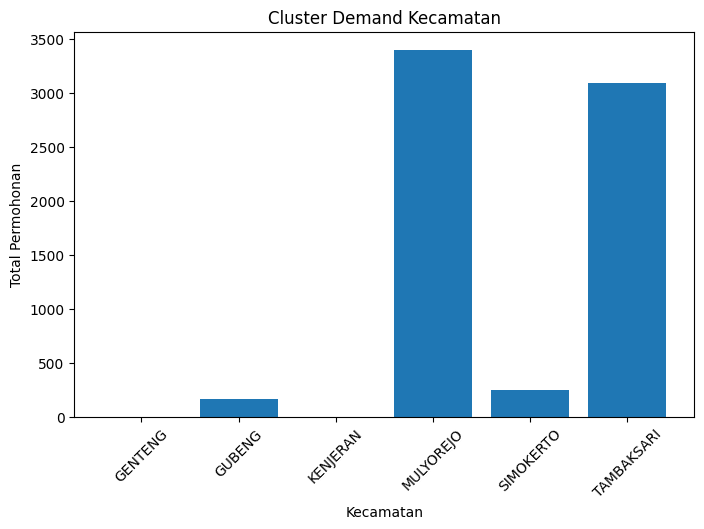

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    agregasi['kecamatan'],
    agregasi['total_permohonan']
)

plt.title("Cluster Demand Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Total Permohonan")

plt.xticks(rotation=45)

plt.show()

PETA

In [199]:
# =========================
# PETA CLUSTER INTERAKTIF
# =========================

import folium

# koordinat kecamatan
koordinat = {
    "GENTENG": [-7.265, 112.747],
    "GUBENG": [-7.276, 112.758],
    "KENJERAN": [-7.235, 112.800],
    "MULYOREJO": [-7.275, 112.785],
    "SIMOKERTO": [-7.245, 112.750],
    "TAMBAKSARI": [-7.255, 112.760],
}

# =========================
# BUAT PETA DASAR
# =========================

peta_cluster = folium.Map(
    location=[-7.26, 112.77],
    zoom_start=12,
    tiles='CartoDB positron'
)

# =========================
# TAMBAHKAN MARKER
# =========================

for _, row in agregasi.iterrows():

    kec = row['kecamatan']

    # warna berdasarkan cluster
    if row['KATEGORI_CLUSTER'] == 'High Demand':
        warna = 'red'

    elif row['KATEGORI_CLUSTER'] == 'Medium Demand':
        warna = 'orange'

    else:
        warna = 'green'

    # marker
    folium.CircleMarker(
        location=koordinat[kec],

        radius=row['total_permohonan'] / 200,

        color=warna,

        fill=True,
        fill_color=warna,
        fill_opacity=0.7,

        popup=f"""
        <b>{kec}</b><br><br>

        <b>Kategori:</b>
        {row['KATEGORI_CLUSTER']}<br><br>

        Total Permohonan:
        {row['total_permohonan']}<br>

        Pasang Baru:
        {row['pasang_baru']}<br>

        Tambah Daya:
        {row['tambah_daya']}<br>

        Rata-rata Selisih Daya:
        {round(row['rata_selisi_daya'],2)}
        """
    ).add_to(peta_cluster)

# =========================
# LEGENDA
# =========================

legend_html = """
<div style="
position: fixed;
top: 20px;
right: 20px;
width: 170px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:12px;
padding: 10px;
">

<b>Cluster Demand</b><br><br>

<i style="color:red;">●</i>
High Demand<br>

<i style="color:orange;">●</i>
Medium Demand<br>

<i style="color:green;">●</i>
Low Demand

</div>
"""

peta_cluster.get_root().html.add_child(
    folium.Element(legend_html)
)

# =========================
# SIMPAN PETA
# =========================

peta_cluster.save("peta_cluster_kecamatan.html")

# tampilkan
peta_cluster

In [107]:
print('agregasi' in globals())

False


streamlit run app.py